# Assignment 6: Data Scraping
```
Course: ENV 700 - Environmental Data Exploration
Author: Student Name
Date: Fall 2026
```

This notebook accompanies the Python lessons on **Data Scraping**. We'll be scraping data from the North Carolina Department of Water Quality (NC DWQ). 

## 1. Setup
* Import packages: `requests`, `BeautifulSoup` (from `bs4`), `pandas` (as `pd`), `seaborn` (as `sns`) and any other packages you wish to use. 
* Set your Seaborn theme's style, context, and any runtime configurations you wish

In [7]:
#Import packages
#Pandas
import pandas as pd

#Web scraping packages
import requests
from bs4 import BeautifulSoup

#Automation tools
import time
from itertools import product

#Plotting
import seaborn as sns
import matplotlib.pyplot as plt

#calendar 
import calendar
#Set Seaborn theme
sns.set_theme(    style="whitegrid",
    context= "notebook",
    palette="dark",
    font_scale=0.8,
    rc={
        "xtick.color" : "navy",
        "ytick.color" : "navy"
    }
)

## 2. Scraping Water Supply Data 
We will be scraping data from the NC DEQs Local Water Supply Planning website, specifically the Durham's 2025 Municipal Local Water Supply Plan (LWSP): 
 * Navigate to https://www.ncwater.org/WUDC/app/LWSP/search.php
 * Set the year to 2025
 * Scroll down and select the LWSP link next to Durham Municipality. 
 * Note the web address: <https://www.ncwater.org/WUDC/app/LWSP/report.php?pwsid=03-32-010&year=2025>

---
### 2.1 Retrieve the website and parse it using BeautifulSoup

In [8]:
# 2.1 Retrieve the website and parse it using BeautifulSoup

url= "https://www.ncwater.org/WUDC/app/LWSP/report.php?pwsid=03-32-010&year=2025"

response = requests.get(url)
response.raise_for_status()

webpage = BeautifulSoup(response.text, "html.parser")
type(webpage)

if webpage.title: 
    print(webpage.title.get_text(strip=True))
else: print("No page title")

DWR :: Local Water Supply Planning


### 2.2 The data we want to collect are listed below:

* From the **1. System Information** section:
    - Water system name
    - Contact Person
    - Ownership
 
* From the **3. Water Supply Sources** section:
    - Maximum Day Use (MGD) - for each month

In the code chunk below scrape these values, assigning them to four separate variables.  
>HINT: The first value should be "`Durham`", the second "`Kieu Tran`", the third "`Municipality`", and the last should be a vector of 12 numeric values (represented as strings)".

In [9]:
# 2.2 Scrape the data into variables

WaterSystem = webpage.select_one("div+ table tr:nth-child(1) td:nth-child(2)").get_text(strip=True)
ContactPerson = webpage.select_one("div+ table tr:nth-child(4) td:nth-child(2)").get_text(strip=True)
Ownership = webpage.select_one("div+ table tr:nth-child(2) td:nth-child(4)").get_text(strip=True)

MaxDayUse = [x.get_text(strip=True) for x in webpage.select("th~ td+ td")] 

MonthOrder = [1, 5, 9, 2, 6, 10, 3, 7, 11, 4, 8, 12]

### 2.3 Construct a dataframe from the scraped data
Convert your scraped data into a dataframe. 
* This dataframe should have a column for each of the 4 variables scraped and a row for the month corresponding to the withdrawal data. 
* Note that you won't likely be able to scrape max water usage data in chronological order.
* Include columns for the month and year the data were collected. 
* Sort the data on year and month.
* Construct a datetime column from the year and month, assuming the day of the month will be the first. 

>🔥**TIP**: : To construct a list from a repeated set of values, use this approach:
>```python
>years_x6 = [2025] * 6
>print(years_x6)
>```

>🔥**TIP**: To construct a datetime column when you just the year and month, you can use the following:
>```python
>df['Date'] = pd.to_datetime({
>    "year": df['Year'],
>    "month": df['Month'],
>    "day": 1
>})
>```

In [10]:
# 2.3 Construct the dataframe from scraped data

df = pd.DataFrame({
    "WaterSystem": WaterSystem,
    "Contact": ContactPerson,
    "Ownership": Ownership,
    "MaxDailyUse": MaxDayUse,
    "Month": MonthOrder,
    "Year": [2025] *12,
})

#change data types to numeric
cols = ["Month", "Year", "MaxDailyUse"]
for col in cols:
    df[col] = pd.to_numeric(df[col])

df['Date'] = pd.to_datetime({
    "year": df['Year'],
    "month": df['Month'],
    "day": 1
})

#add in month abbs
df["month_abb"] = pd.Categorical(
    values=df["Date"].dt.month_name().str[:3],
    categories=calendar.month_abbr[1:]
)

df = df.sort_values("Date")

df

,WaterSystem,Contact,Ownership,MaxDailyUse,Month,Year,Date,month_abb
0,Durham,Kieu Tran,Municipality,40.24,1,2025,2025-01-01,Jan
3,Durham,Kieu Tran,Municipality,33.81,2,2025,2025-02-01,Feb
6,Durham,Kieu Tran,Municipality,36.53,3,2025,2025-03-01,Mar
9,Durham,Kieu Tran,Municipality,37.95,4,2025,2025-04-01,Apr
1,Durham,Kieu Tran,Municipality,37.38,5,2025,2025-05-01,May
4,Durham,Kieu Tran,Municipality,36.84,6,2025,2025-06-01,Jun
7,Durham,Kieu Tran,Municipality,38.04,7,2025,2025-07-01,Jul
10,Durham,Kieu Tran,Municipality,35.20,8,2025,2025-08-01,Aug
2,Durham,Kieu Tran,Municipality,37.91,9,2025,2025-09-01,Sep
5,Durham,Kieu Tran,Municipality,36.90,10,2025,2025-10-01,Oct


### 2.4 Plot the data
* Create a line plot of the maximum daily withdrawals across the months for 2024
* Label the x-axis with month names or abbreviated month names. (Note, you may have to do some more wrangling...)

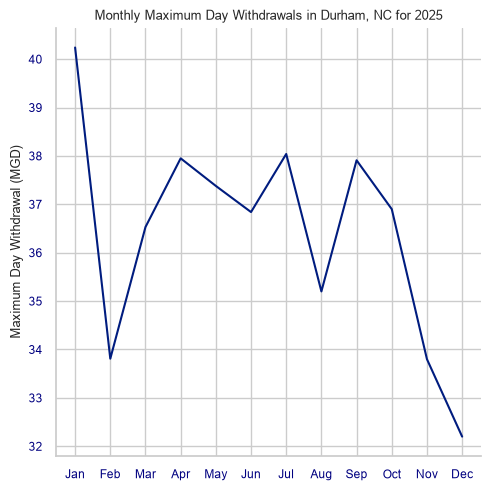

In [11]:
# 2.4 Plot the data
g = sns.relplot(
    data=df,
    x = "month_abb",
    y= "MaxDailyUse",
    kind="line"
).set(
    title="Monthly Maximum Day Withdrawals in Durham, NC for 2025",
    xlabel="",
    ylabel="Maximum Day Withdrawal (MGD)"
)

## 3. Automating the Scraping Process
### 3.1 Construct the scraping function
Note that the PWSID and the year appear in the web address for the page we scraped. Construct a function with two inputs, "PWSID" and "year", that:
  - Creates a URL pointing to the LWSP for that PWSID for the given year
  - Creates a website object and scrapes the data from that object (just as you did above)
  - Constructs a dataframe from the scraped data, mostly as you did above, but includes the PWSID and year provided as function inputs in the dataframe. 
  - Returns the dataframe as the function's output

In [12]:
# 3.1 Create a scraping function

def scrape_it (PWSID, year):
# website to scrape
    url= f"https://www.ncwater.org/WUDC/app/LWSP/report.php?pwsid={PWSID}&year={year}"
    response = requests.get(url)
    response.raise_for_status()
    webpage = BeautifulSoup(response.text, "html.parser")  

# variables
    WaterSystem = webpage.select_one("div+ table tr:nth-child(1) td:nth-child(2)").get_text(strip=True)
    ContactPerson = webpage.select_one("div+ table tr:nth-child(4) td:nth-child(2)").get_text(strip=True)
    Ownership = webpage.select_one("div+ table tr:nth-child(2) td:nth-child(4)").get_text(strip=True)
    MaxDayUse = [x.get_text(strip=True) for x in webpage.select("th~ td+ td")] 
    MonthOrder = [1, 5, 9, 2, 6, 10, 3, 7, 11, 4, 8, 12]

# dataframe
    df = pd.DataFrame({
    "PWSID": PWSID,
    "WaterSystem": WaterSystem,
    "Contact": ContactPerson,
    "Ownership": Ownership,
    "MaxDailyUse": MaxDayUse,
    "Month": MonthOrder,
    "Year": year,
    })

    cols = ["Month", "Year", "MaxDailyUse"]
    for col in cols:
        df[col] = pd.to_numeric(df[col])

    df['Date'] = pd.to_datetime({
        "year": df['Year'],
        "month": df['Month'],
        "day": 1
    })

    df["month_abb"] = pd.Categorical(
        values=df["Date"].dt.month_name().str[:3],
        categories=calendar.month_abbr[1:]
    )

    df = df.sort_values("Date")

    return df


### 3.2 Fetch and plot data for Durham (PWSID=`03-32-010`) in 2020
* Use the function above to extract and plot max daily withdrawals for Durham (PWSID=`03-32-010`) for each month in 2020.
* Reveal the structure of your dataframe using the `info()` function. 
* Then create plot your data in a line plot as above: Max Usage by Month.

In [13]:
# 3.2.1 Scrape data for 03-32-010 in 2020 & display its structure

df_32 = scrape_it("03-32-010", 2020)

df_32

,PWSID,WaterSystem,Contact,Ownership,MaxDailyUse,Month,Year,Date,month_abb
0,03-32-010,Durham,Kieu Tran,Municipality,36.01,1,2020,2020-01-01,Jan
3,03-32-010,Durham,Kieu Tran,Municipality,32.05,2,2020,2020-02-01,Feb
6,03-32-010,Durham,Kieu Tran,Municipality,37.29,3,2020,2020-03-01,Mar
9,03-32-010,Durham,Kieu Tran,Municipality,32.37,4,2020,2020-04-01,Apr
1,03-32-010,Durham,Kieu Tran,Municipality,36.98,5,2020,2020-05-01,May
4,03-32-010,Durham,Kieu Tran,Municipality,40.61,6,2020,2020-06-01,Jun
7,03-32-010,Durham,Kieu Tran,Municipality,43.63,7,2020,2020-07-01,Jul
10,03-32-010,Durham,Kieu Tran,Municipality,41.93,8,2020,2020-08-01,Aug
2,03-32-010,Durham,Kieu Tran,Municipality,41.69,9,2020,2020-09-01,Sep
5,03-32-010,Durham,Kieu Tran,Municipality,40.56,10,2020,2020-10-01,Oct


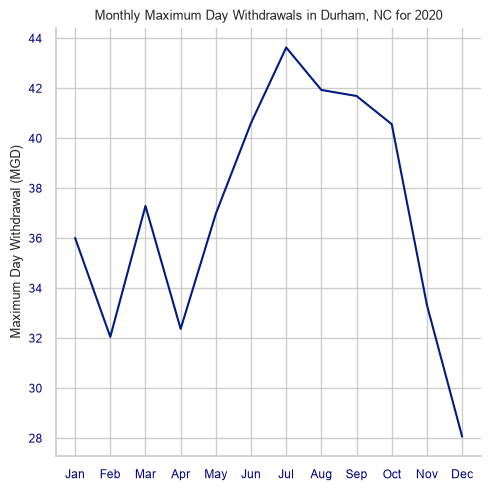

In [14]:
# 3.2.2 Plot the data

g32 = sns.relplot(
    data=df_32,
    x = "month_abb",
    y= "MaxDailyUse",
    kind="line"
).set(
    title="Monthly Maximum Day Withdrawals in Durham, NC for 2020",
    xlabel="",
    ylabel="Maximum Day Withdrawal (MGD)"
)

### 3.3 Fetch and plot data for Cary (PWSID=`03-92-020`) in 2020

In [15]:
# 3.3.1 Fetch and plot data for Cary (PWSID=`03-92-020`) in 2020

df_33 = scrape_it("03-92-020", 2020)

df_33

,PWSID,WaterSystem,Contact,Ownership,MaxDailyUse,Month,Year,Date,month_abb
0,03-92-020,Cary,Jamie Revels,Municipality,21.95,1,2020,2020-01-01,Jan
3,03-92-020,Cary,Jamie Revels,Municipality,17.70,2,2020,2020-02-01,Feb
6,03-92-020,Cary,Jamie Revels,Municipality,20.56,3,2020,2020-03-01,Mar
9,03-92-020,Cary,Jamie Revels,Municipality,19.32,4,2020,2020-04-01,Apr
1,03-92-020,Cary,Jamie Revels,Municipality,23.22,5,2020,2020-05-01,May
4,03-92-020,Cary,Jamie Revels,Municipality,26.19,6,2020,2020-06-01,Jun
7,03-92-020,Cary,Jamie Revels,Municipality,28.01,7,2020,2020-07-01,Jul
10,03-92-020,Cary,Jamie Revels,Municipality,25.40,8,2020,2020-08-01,Aug
2,03-92-020,Cary,Jamie Revels,Municipality,25.49,9,2020,2020-09-01,Sep
5,03-92-020,Cary,Jamie Revels,Municipality,23.60,10,2020,2020-10-01,Oct


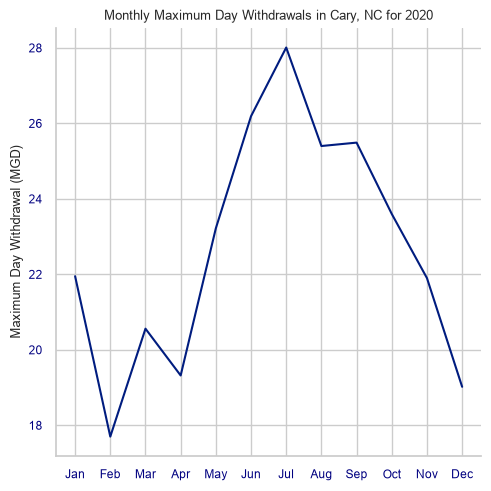

In [16]:
# 3.3.2 Plot the Cary data
g33 = sns.relplot(
    data=df_33,
    x = "month_abb",
    y= "MaxDailyUse",
    kind="line"
).set(
    title="Monthly Maximum Day Withdrawals in Cary, NC for 2020",
    xlabel="",
    ylabel="Maximum Day Withdrawal (MGD)"
)

### 3.4 Examine monthy max discharge from 2020-2025
* Use list comprehension (or other methods) to produce a list of dataframes, one for each year in 2020 to 2025
* Concatenate these dataframes into a single one including data for all years
* Create a line plot of max monthly discharge across the full timespan (x-axis labels do not have to be months)

In [17]:
# 3.4.1 Generate a list of the dataframes
years = [2020, 2021, 2022, 2023, 2024, 2025]

# i am confused why we are creating independent dataframes to then combine them
# wouldnt it be easier to use pd.concat to do it for all of them at once?
# like we did in M6-L-5.1 exercise

# this code uses the year list to make callable dataframes with dfs[year]
dfs = {
    year: scrape_it("03-32-010", year)
    for year in years
} #this is the list of dataframes

# 3.4.2 Combine them into a single dataframe
all = pd.concat(dfs, ignore_index=True) #ignore index makes it flat for us

all

#could we not have done the below? this feels more intuitive to me and matches before
# but i also understand the desire for multiple dataframes
#df_all = pd.concat(
#    [scrape_it("03-32-010", year) for year in years]
#) I did run this and got a very similar result

,PWSID,WaterSystem,Contact,Ownership,MaxDailyUse,Month,Year,Date,month_abb
0,03-32-010,Durham,Kieu Tran,Municipality,36.01,1,2020,2020-01-01,Jan
1,03-32-010,Durham,Kieu Tran,Municipality,32.05,2,2020,2020-02-01,Feb
2,03-32-010,Durham,Kieu Tran,Municipality,37.29,3,2020,2020-03-01,Mar
3,03-32-010,Durham,Kieu Tran,Municipality,32.37,4,2020,2020-04-01,Apr
4,03-32-010,Durham,Kieu Tran,Municipality,36.98,5,2020,2020-05-01,May
...,...,...,...,...,...,...,...,...,...
67,03-32-010,Durham,Kieu Tran,Municipality,35.20,8,2025,2025-08-01,Aug
68,03-32-010,Durham,Kieu Tran,Municipality,37.91,9,2025,2025-09-01,Sep
69,03-32-010,Durham,Kieu Tran,Municipality,36.90,10,2025,2025-10-01,Oct
70,03-32-010,Durham,Kieu Tran,Municipality,33.80,11,2025,2025-11-01,Nov


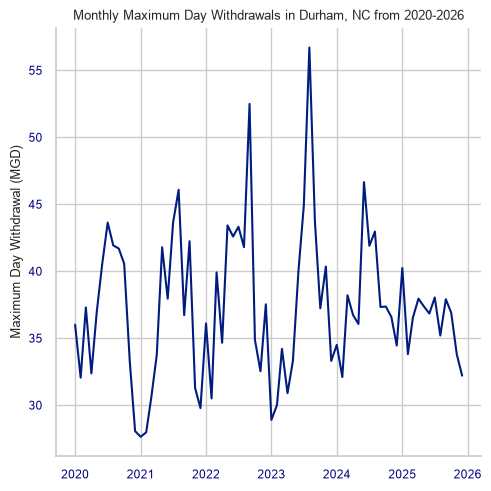

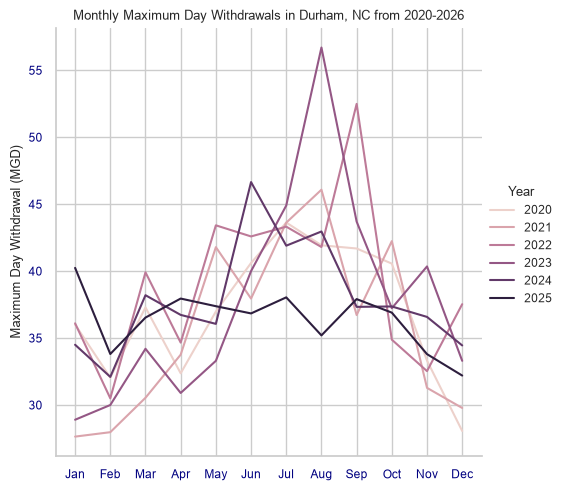

In [18]:
# 3.4.3 Plot
g_all_timeline = sns.relplot(
    data=all,
    x = "Date",
    y= "MaxDailyUse",
    kind="line",
    #hue="Year"
).set(
    title="Monthly Maximum Day Withdrawals in Durham, NC from 2020-2026",
    xlabel="",
    ylabel="Maximum Day Withdrawal (MGD)"
)

g_all_yearly =g_all_timeline = sns.relplot(
    data=all,
    x = "month_abb",
    y= "MaxDailyUse",
    kind="line",
    hue="Year",
).set(
    title="Monthly Maximum Day Withdrawals in Durham, NC from 2020-2026",
    xlabel="",
    ylabel="Maximum Day Withdrawal (MGD)"
)

#I plotted both because I found it most helpful to have the additional context of the monthly comparisons, not just the full timeline